# Clustering exploration — first pass

**Question.** EDGAR looks for *one* interpretable model per dataset, but a recorded population may be genuinely heterogeneous. Can a naive clustering carve the population into sub-populations we could later hand to EDGAR separately, so that each cluster gets a more predictive + interpretable model?

This is a **rough, intuition-building** pass. We keep **all cells, no filtering** — a large untuned/"junk" cluster is itself informative (it may be exactly what manual preprocessing removes).

Three targets:
1. **Cells by tuning curve** — functional similarity (the core EDGAR hypothesis).
2. **Trials by population vector** — internal-state / trial-regime structure.
3. **Cells by spontaneous activity** (Stringer only) — does spontaneous structure predict functional tuning?

**Caveats to hold onto:** clustering *always* returns clusters — lean on silhouette + stability, not their mere existence. Normalization (amplitude vs shape) changes cell clusters. Trial clusters are likely dominated by the stimulus — the orientation-removed residual is the real test.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import clustering as C

STRINGER = '/home/dabin/data/stringer_2020/gratings_drifting_GT1_2019_04_12_1.npy'
JACOB = '/home/dabin/data/jacob_gratings_202507/parsed/BZ015_2025-07-03_2'

# UMAP on 20k points is slow; cap it for the embedding plots only.
UMAP_MAX = 8000
rng = np.random.default_rng(0)

## 1. Load & describe

Stringer GT1 : (20616, 4282) (cells, trials)  spont_u (20616, 128)
Jacob BZ015  : (15166, 1026) (cells, trials)


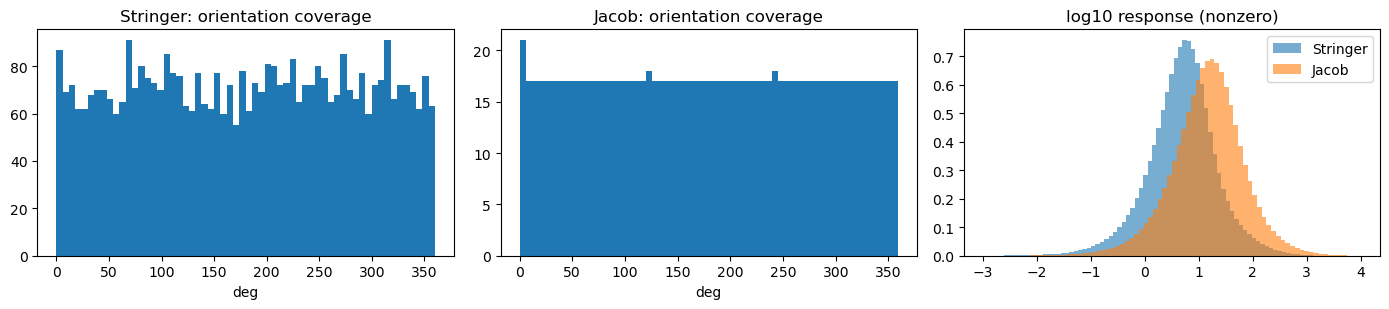

In [36]:
s = C.load_stringer(STRINGER)
j = C.load_jacob(JACOB)

print('Stringer GT1 :', s['response'].shape, '(cells, trials)  spont_u', s['spont_u'].shape)
print('Jacob BZ015  :', j['response'].shape, '(cells, trials)')

fig, ax = plt.subplots(1, 3, figsize=(14, 3.2))
for a, (name, d) in zip(ax[:2], [('Stringer', s), ('Jacob', j)]):
    a.hist(np.rad2deg(d['angles']), bins=60)
    a.set_title(f'{name}: orientation coverage'); a.set_xlabel('deg')
ax[2].hist(np.log10(s['response'][s['response'] > 0].ravel() + 1e-3), bins=80, alpha=0.6, label='Stringer', density=True)
ax[2].hist(np.log10(j['response'][j['response'] > 0].ravel() + 1e-3), bins=80, alpha=0.6, label='Jacob', density=True)
ax[2].set_title('log10 response (nonzero)'); ax[2].legend()
plt.tight_layout(); plt.show()

_Observation:_ both datasets tile orientation densely over 0–360°. Note the fraction of zero responses (silent cells/trials) before drawing conclusions — with no filtering, many cells barely respond.

# Naive clustering attempt

In [44]:
from sklearn.cluster import KMeans

initialize = lambda: {'clusters': None, 'emb': None}
data = {'stringer' : initialize(), 'jacob' : initialize()}
data['stringer']['clusters'] = KMeans(n_clusters=4, n_init=10, random_state=0).fit_predict(s['response'])
data['stringer']['emb'] = C.umap_embed(s['response'])

data['jacob']['clusters'] = KMeans(n_clusters=4, n_init=10, random_state=0).fit_predict(j['response'])
data['jacob']['emb'] = C.umap_embed(j['response'])

/home/dabin/miniconda3/envs/shared/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/dabin/miniconda3/envs/shared/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


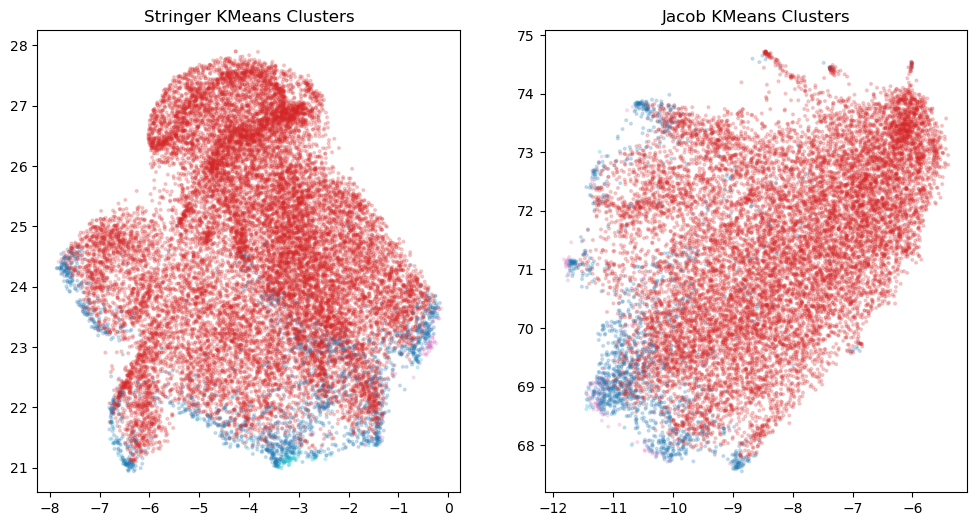

In [ ]:
# Use UMAP visualisation 
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].scatter(data['stringer']['emb'][:, 0], data['stringer']['emb'][:, 1], c=data['stringer']['clusters'], s=4, cmap="tab10", alpha=0.2)
axes[1].scatter(data['jacob']['emb'][:, 0], data['jacob']['emb'][:, 1], c=data['jacob']['clusters'], s=4, cmap="tab10", alpha=0.2)
axes[0].set_title('Stringer KMeans Clusters'); axes[1].set_title('Jacob KMeans Clusters')
plt.show()

preferred angle shape (15166,)
(15166,)


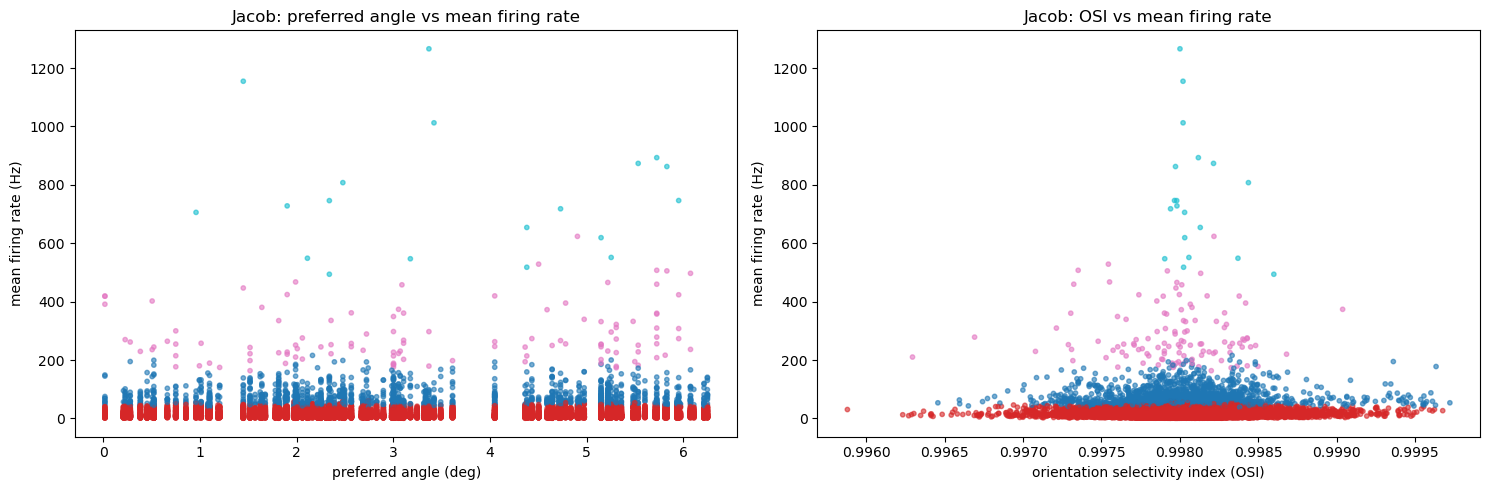

preferred angle shape (20616,)
(20616,)


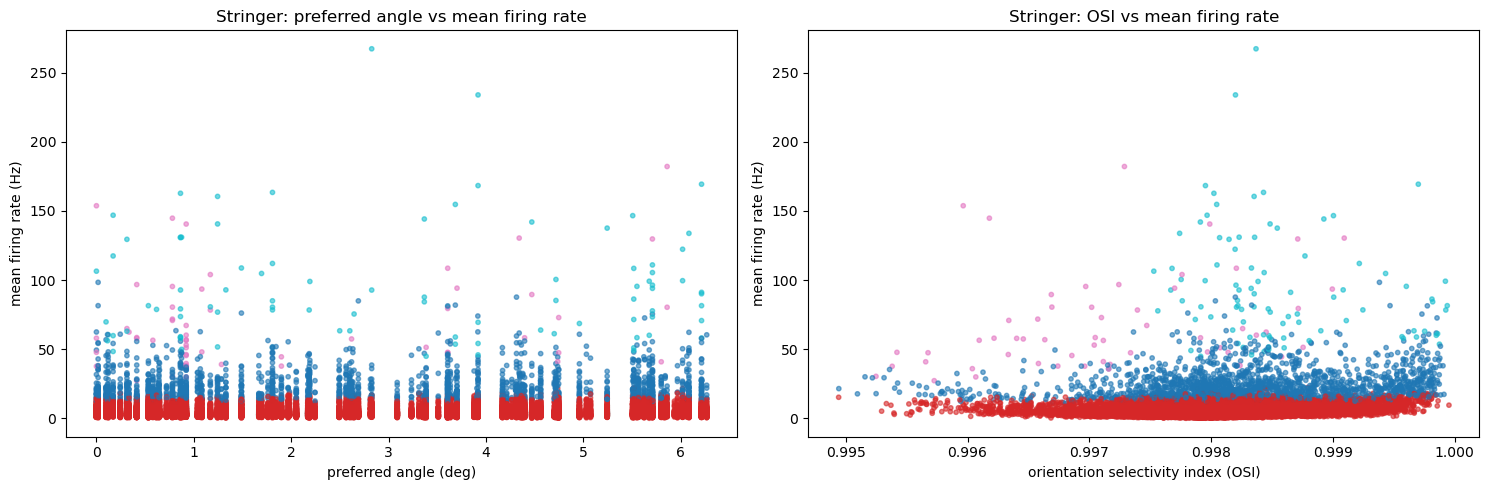

In [61]:
# Try plotting the clusters against some of these measures 
# 0. preferred angle - just to check
# 1. orientation selectivity of the cell

def plot_cluster_measures(data_name, data):
    if data_name == 'stringer':
        raw_data = s
    elif data_name == 'jacob':
        raw_data = j
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # plot both against the mean firing rate of the cell 
    mean_fr = raw_data['response'].mean(axis=1)

    # preferred angle - base it on smoothed tuning curve 
    smoothed_tc = C.build_tuning_curves(raw_data['response'], raw_data['angles'], n_bins=120, normalize='l2')

    preferred_angle = raw_data['angles'][smoothed_tc.argmax(axis=1)]
    print(f"preferred angle shape {preferred_angle.shape}")

    axes[0].scatter(preferred_angle, mean_fr, s=10, alpha=0.6, c=data[data_name]['clusters'], cmap='tab10')
    axes[0].set_xlabel('preferred angle (deg)'); axes[0].set_ylabel('mean firing rate (Hz)'); axes[0].set_title(f'{data_name.capitalize()}: preferred angle vs mean firing rate')

    # orientation selectivity of the cell - use OSI (write out explicitly)
    osi = np.zeros(raw_data['response'].shape[0])
    for i in range(raw_data['response'].shape[0]):
        angles_rad = np.deg2rad(raw_data['angles'])
        response = raw_data['response'][i]
        vector_sum = np.sum(response * np.exp(1j * 2 * angles_rad))
        osi[i] = np.abs(vector_sum) / np.sum(response)

    print(osi.shape)
    axes[1].scatter(osi, mean_fr, s=10, alpha=0.6, c=data[data_name]['clusters'], cmap='tab10')
    axes[1].set_xlabel('orientation selectivity index (OSI)'); axes[1].set_ylabel('mean firing rate (Hz)'); axes[1].set_title(f'{data_name.capitalize()}: OSI vs mean firing rate')
    plt.tight_layout()
    plt.show()

plot_cluster_measures('jacob', data)
plot_cluster_measures('stringer', data)

In [62]:
from sklearn.cluster import KMeans

K_CLUSTERS = 10

initialize = lambda: {'clusters': None, 'emb': None}
data = {'stringer' : initialize(), 'jacob' : initialize()}
data['stringer']['clusters'] = KMeans(n_clusters=K_CLUSTERS, n_init=10, random_state=0).fit_predict(s['response'])
data['stringer']['emb'] = C.umap_embed(s['response'])

data['jacob']['clusters'] = KMeans(n_clusters=K_CLUSTERS, n_init=10, random_state=0).fit_predict(j['response'])
data['jacob']['emb'] = C.umap_embed(j['response'])

/home/dabin/miniconda3/envs/shared/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/dabin/miniconda3/envs/shared/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


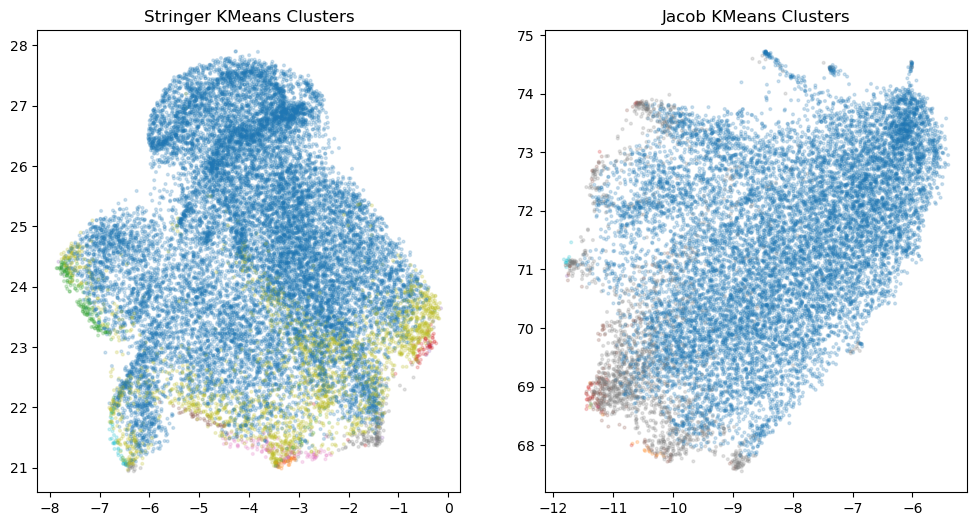

In [64]:
# Use UMAP visualisation 
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].scatter(data['stringer']['emb'][:, 0], data['stringer']['emb'][:, 1], c=data['stringer']['clusters'], s=4, cmap="tab10", alpha=0.2)
axes[1].scatter(data['jacob']['emb'][:, 0], data['jacob']['emb'][:, 1], c=data['jacob']['clusters'], s=4, cmap="tab10", alpha=0.2)
axes[0].set_title('Stringer KMeans Clusters'); axes[1].set_title('Jacob KMeans Clusters')
plt.show()

preferred angle shape (15166,)
(15166,)


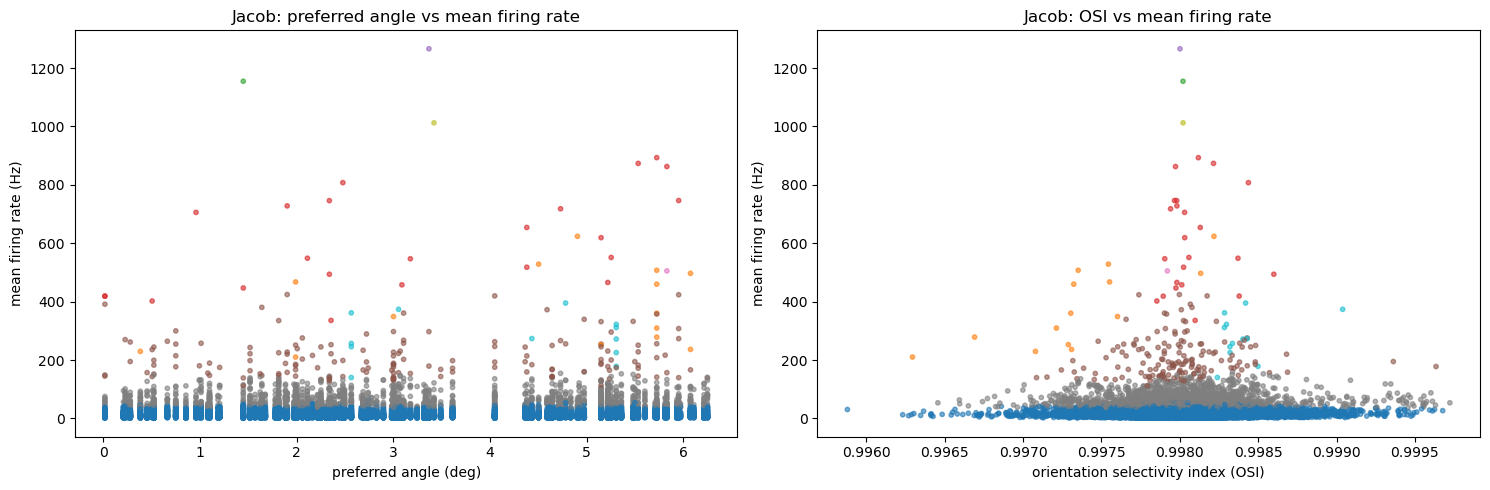

preferred angle shape (20616,)
(20616,)


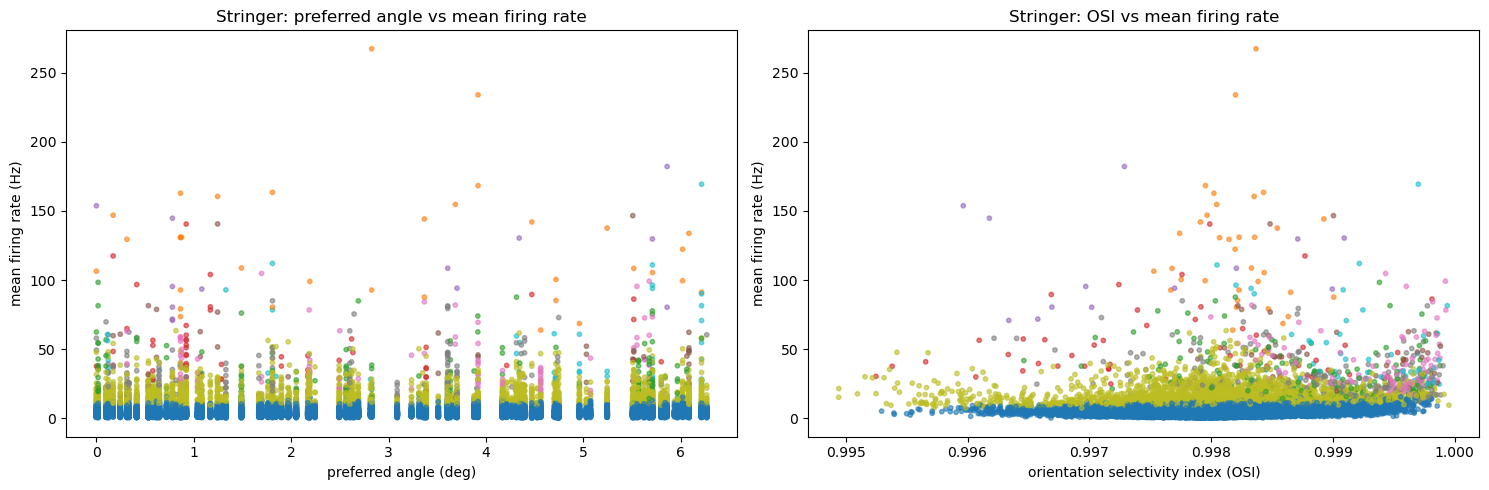

In [63]:
plot_cluster_measures('jacob', data)
plot_cluster_measures('stringer', data)

## 2. Cells by tuning curve

Feature = per-cell orientation tuning curve (36 bins), L2-normalized so we cluster **shape not amplitude**. PCA → silhouette k-sweep → KMeans + Ward → UMAP → per-cluster mean curves → stability.

/home/dabin/miniconda3/envs/shared/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


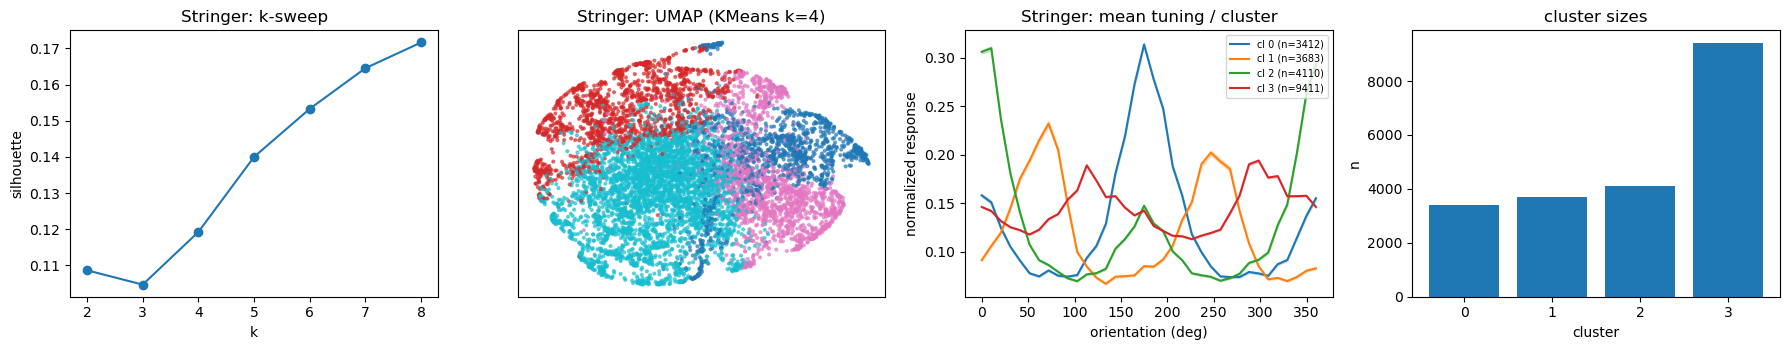

Stringer: stability ARI(k=4) = 0.757 | KMeans-vs-Ward {'adjusted_rand': 0.2067206361999753, 'normalized_mi': 0.2510469903614101}


/home/dabin/miniconda3/envs/shared/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


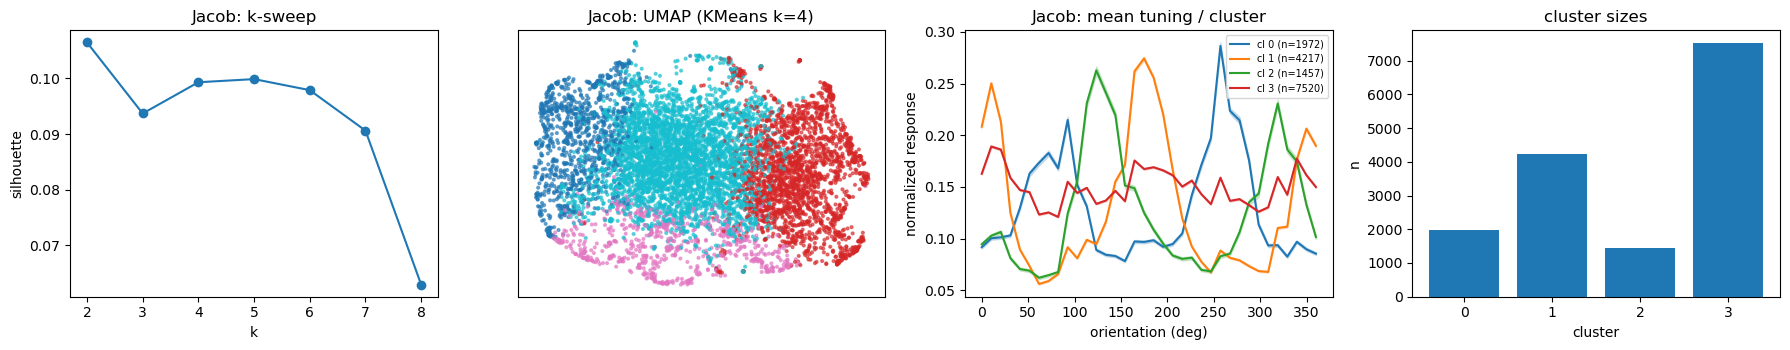

Jacob: stability ARI(k=4) = 0.785 | KMeans-vs-Ward {'adjusted_rand': 0.23611548334677623, 'normalized_mi': 0.3063316621027404}


In [6]:
def cell_tuning_analysis(d, name, k=4):
    tc = C.build_tuning_curves(d['response'], d['angles'], n_bins=36, normalize='l2')
    X = C.pca_reduce(tc, 100)
    sweep = C.sweep_k(X, ks=range(2, 9), method='kmeans')
    lab_km = C.cluster_kmeans(X, k)
    lab_ward = C.cluster_agglomerative(X, k)
    stab = C.cluster_stability(X, 'kmeans', k, n_subsamples=8)
    agree = C.compare_labelings(lab_km, lab_ward)

    idx = rng.choice(X.shape[0], min(UMAP_MAX, X.shape[0]), replace=False)
    emb = C.umap_embed(X[idx])

    fig, ax = plt.subplots(1, 4, figsize=(18, 3.6))
    ax[0].plot(sweep.index, sweep['silhouette'], 'o-'); ax[0].set_xlabel('k'); ax[0].set_ylabel('silhouette'); ax[0].set_title(f'{name}: k-sweep')
    C.plot_embedding(emb, lab_km[idx], ax=ax[1], title=f'{name}: UMAP (KMeans k={k})')
    C.plot_cluster_tuning_curves(tc, lab_km, ax=ax[2], title=f'{name}: mean tuning / cluster')
    C.plot_cluster_sizes(lab_km, ax=ax[3], title='cluster sizes')
    plt.tight_layout(); plt.show()
    print(f'{name}: stability ARI(k={k}) = {stab:.3f} | KMeans-vs-Ward {agree}')
    return tc, X, lab_km

tc_s, X_s, lab_s = cell_tuning_analysis(s, 'Stringer', k=4)
tc_j, X_j, lab_j = cell_tuning_analysis(j, 'Jacob', k=4)

/home/dabin/miniconda3/envs/shared/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


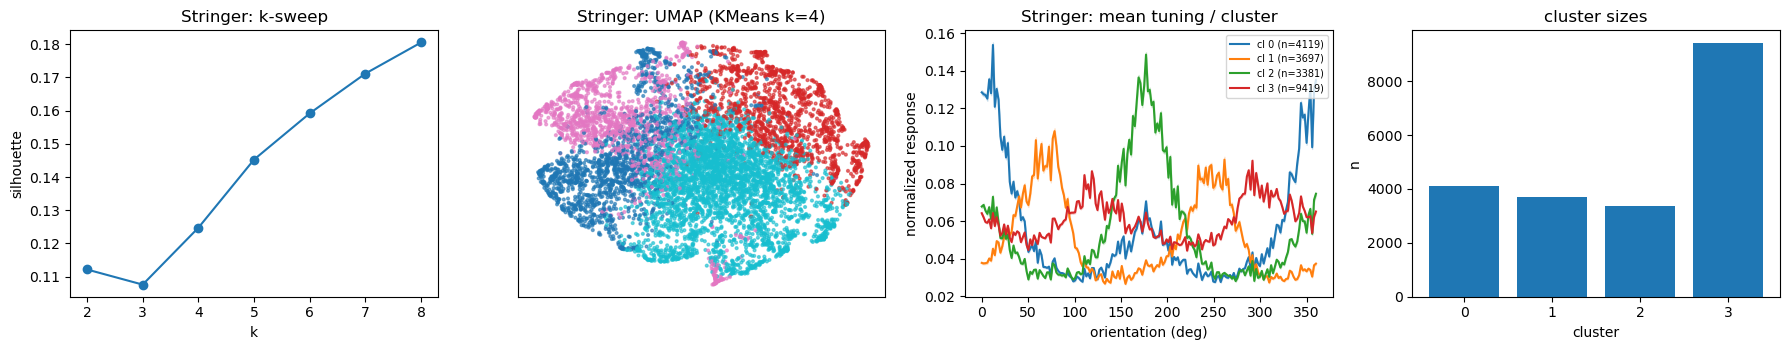

Stringer: stability ARI(k=4) = 0.640 | KMeans-vs-Ward {'adjusted_rand': 0.2573899495734015, 'normalized_mi': 0.3097378961456695}


/home/dabin/miniconda3/envs/shared/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


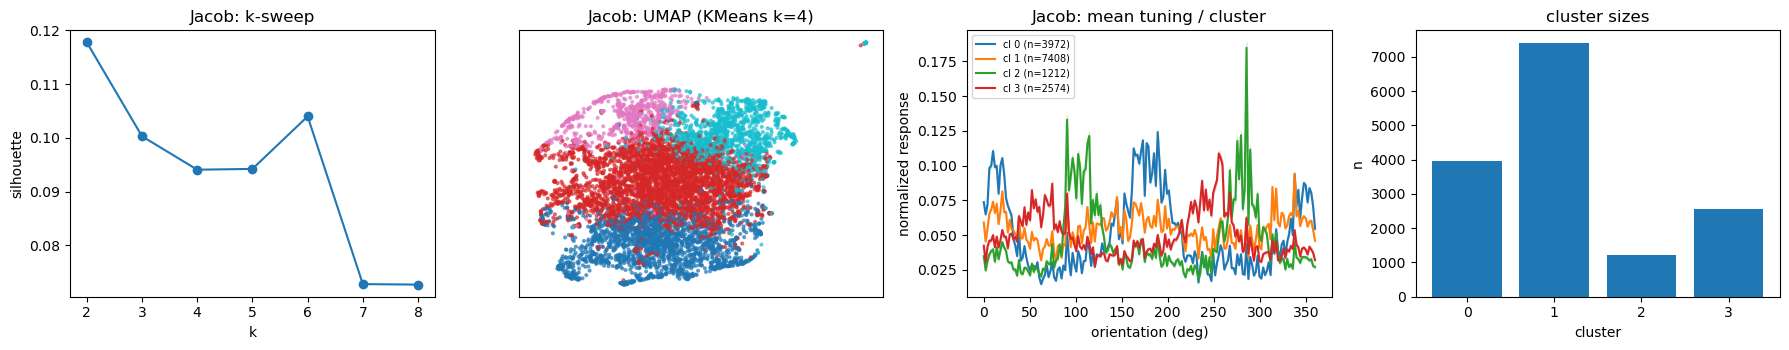

Jacob: stability ARI(k=4) = 0.844 | KMeans-vs-Ward {'adjusted_rand': 0.29911260228326675, 'normalized_mi': 0.3187631263506874}


In [ ]:
tc_s, X_s, lab_s = cell_tuning_analysis(s, 'Stringer', k=4)
tc_j, X_j, lab_j = cell_tuning_analysis(j, 'Jacob', k=4)

_Observation:_ if silhouette rises monotonically with k and never peaks, the tuning-curve space is more of a **continuum** than a set of discrete islands — clusters are cuts through a smooth manifold, not natural kinds. Check whether the per-cluster mean curves are qualitatively distinct (e.g. unimodal vs bimodal, sharp vs broad) — that distinctness, not the silhouette value, is what would justify running EDGAR per-cluster. Cross-check KMeans vs Ward agreement and stability ARI before believing any partition.

### Normalization sensitivity
Does the clustering survive a different normalization? If shape-based (L2) and amplitude-preserving (raw) clusterings disagree strongly, that tells us what the clusters are really keyed on.

In [4]:
for norm in ['l2', 'zscore', None]:
    tc = C.build_tuning_curves(s['response'], s['angles'], n_bins=36, normalize=norm)
    lab = C.cluster_kmeans(C.pca_reduce(tc, 20), 4)
    cmp = C.compare_labelings(lab_s, lab)
    print(f'Stringer norm={str(norm):7s}  vs L2-baseline: ARI={cmp["adjusted_rand"]:.3f}  NMI={cmp["normalized_mi"]:.3f}')

Stringer norm=l2       vs L2-baseline: ARI=1.000  NMI=1.000


Stringer norm=zscore   vs L2-baseline: ARI=0.403  NMI=0.520


Stringer norm=None     vs L2-baseline: ARI=0.024  NMI=0.011


## 3. Trials by population vector

Cluster trials by the population response vector. **Key control:** colour the embedding by the trial's orientation — if trial clusters simply recover the stimulus, they carry no extra information. Then repeat on the **orientation-mean-removed residual** to look for genuine internal-state structure beyond the stimulus.

/home/dabin/code/EDGAR-gamma/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/home/dabin/code/EDGAR-gamma/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


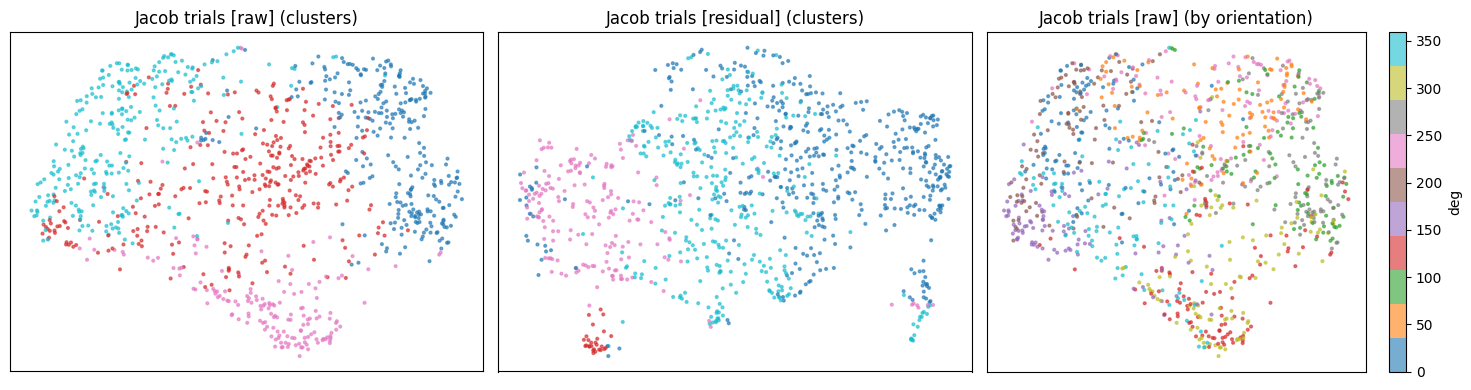

/home/dabin/code/EDGAR-gamma/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/home/dabin/code/EDGAR-gamma/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


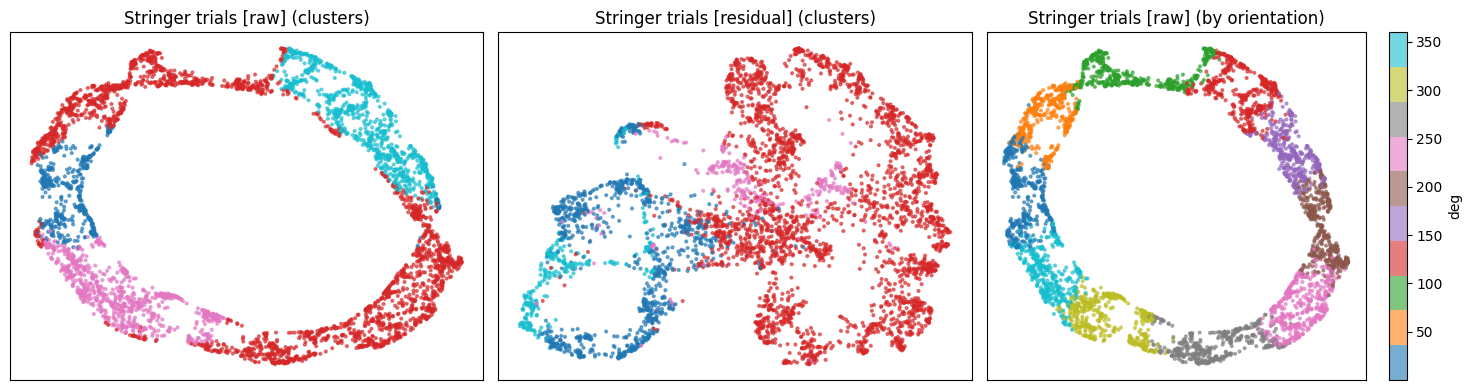

In [5]:
def trial_analysis(d, name, k=4):
    fig, ax = plt.subplots(1, 3, figsize=(15, 4))
    for col, remove in enumerate([False, True]):
        tm = C.trial_population_matrix(d['response'], d['angles'], remove_orientation_mean=remove)
        X = C.pca_reduce(tm, 20)
        lab = C.cluster_kmeans(X, k)
        emb = C.umap_embed(X)
        tag = 'residual' if remove else 'raw'
        C.plot_embedding(emb, lab, ax=ax[col], title=f'{name} trials [{tag}] (clusters)')
        if col == 0:
            sc = C.plot_embedding(emb, lab, ax=ax[2], title=f'{name} trials [raw] (by orientation)', c=np.rad2deg(d['angles']))
            plt.colorbar(sc, ax=ax[2], label='deg')
    plt.tight_layout(); plt.show()

trial_analysis(j, 'Jacob', k=4)
trial_analysis(s, 'Stringer', k=4)

_Observation:_ compare the middle (raw clusters) and right (coloured by orientation) panels — if they line up, "trial clusters" are just the stimulus. The left panel (residual) is the honest test: any remaining structure there is a candidate internal-state signal worth chasing.

## 4. Cells by spontaneous activity (Stringer only)

Feature = each cell's loading on the spontaneous-activity PCs (`spont_u`). Cluster cells on spontaneous structure, then ask whether those clusters align with the **tuning-curve** clusters from section 2. High agreement → spontaneous co-activation predicts functional tuning; near-zero → they are independent axes of population structure.

/home/dabin/code/EDGAR-gamma/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


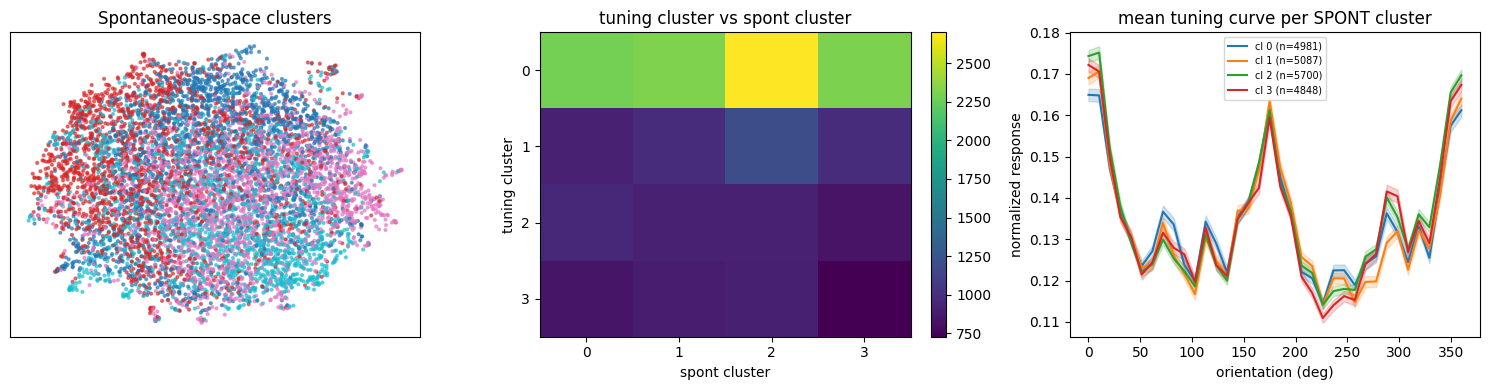

tuning-vs-spontaneous agreement: {'adjusted_rand': 0.0005068316059334937, 'normalized_mi': 0.0007286121120210197}


In [6]:
X_sp = C.pca_reduce(s['spont_u'], 20)
lab_sp = C.cluster_kmeans(X_sp, 4)
cmp = C.compare_labelings(lab_s, lab_sp)

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
idx = rng.choice(X_sp.shape[0], min(UMAP_MAX, X_sp.shape[0]), replace=False)
C.plot_embedding(C.umap_embed(X_sp[idx]), lab_sp[idx], ax=ax[0], title='Spontaneous-space clusters')
C.plot_crosstab(lab_s, lab_sp, ax=ax[1], title='tuning cluster vs spont cluster', xlabel='spont cluster', ylabel='tuning cluster')
C.plot_cluster_tuning_curves(tc_s, lab_sp, ax=ax[2], title='mean tuning curve per SPONT cluster')
plt.tight_layout(); plt.show()
print('tuning-vs-spontaneous agreement:', cmp)

_Observation:_ if the crosstab is roughly uniform and the per-spont-cluster mean tuning curves overlap (ARI/NMI near 0), spontaneous structure does **not** predict functional tuning — clustering on spontaneous alone would not recover the functional sub-populations. That is a clean negative worth recording either way.

## Takeaways (fill in after running)

- Are the tuning-curve clusters discrete or a continuum (silhouette peak? stability? distinct mean curves)?
- Is there a large silent/untuned cluster — the thing manual preprocessing removes?
- Do trial clusters carry anything beyond orientation?
- Does spontaneous structure predict functional tuning?
- **Verdict for EDGAR:** is per-cluster model discovery plausibly worth it, or is the population too continuous to split cleanly?

# Jacob's data - is there spontaneous information? 

I have access to Jacob's suite2p output. I believe Jacob did collect spontaneous activity in